# Análise de Estabilidade e Despacho Energético no Subsistema Nordeste: Impactos da Intermitência Renovável no SIN (2025-2026)


---


#### Vitória Emanuele de Sousa Silva | contato: vitoriaemanueledesousa@gmail.com


---



**I. Escopo:** Avaliação da estabilidade operativa do Subsistema Nordeste sob o paradigma da alta penetração de fontes renováveis variáveis (eólica e fotovoltaica) entre 2025 e 2026. O estudo foca na resiliência regional e no impacto do excedente de geração renovável no Sistema Interligado Nacional (SIN).

**II. Desafio:** Modelar e evidenciar o fenômeno da "Curva do Pato" (Duck Curve) no cenário nordestino. O desafio técnico consiste em analisar o desequilíbrio entre a rampa de descida da geração solar e a ascensão do pico de carga noturno, identificando os gargalos que elevam o risco de instabilidade na frequência e tensão da rede.

**III. Projeto de Visualização:**

**IV. Mapeamento:**

### 1. Importação das bibliotecas e carregamento dos Datasets:

In [4]:
import pandas as pd
import matplotlib.pyplot as plt


Os datasets anuais do ONS (2025 e 2026) são carregados individualmente para permitir uma validação inicial de integridade.

In [5]:
df_2025 = pd.read_csv('./datasets/BALANCO_ENERGIA_SUBSISTEMA_2025.csv', sep=';')

# Create a DataFrame to display column information in a more structured way
column_info = pd.DataFrame({
    'Column Name': df_2025.columns,
    'Data Type': df_2025.dtypes,
    'Non-Null Count': df_2025.count(),
})

display(column_info.reset_index(drop=True))

,Column Name,Data Type,Non-Null Count
0,id_subsistema,str,43800
1,nom_subsistema,str,43800
2,din_instante,str,43800
3,val_gerhidraulica,float64,43800
4,val_gertermica,float64,43800
5,val_gereolica,float64,43800
6,val_gersolar,float64,43800
7,val_carga,float64,43800
8,val_intercambio,float64,43800


In [6]:
df_2026 = pd.read_csv('./datasets/BALANCO_ENERGIA_SUBSISTEMA_2026.csv', sep=';')

column_info = pd.DataFrame({
    'Column Name': df_2026.columns,
    'Data Type': df_2026.dtypes,
    'Non-Null Count': df_2026.count(),
})

display(column_info.reset_index(drop=True))

,Column Name,Data Type,Non-Null Count
0,id_subsistema,str,8520
1,nom_subsistema,str,8520
2,din_instante,str,8520
3,val_gerhidraulica,float64,8520
4,val_gertermica,float64,8520
5,val_gereolica,float64,8520
6,val_gersolar,float64,8520
7,val_carga,float64,8520
8,val_intercambio,float64,8520



#### 1.2 Dicionário de Variáveis (Dataset ONS)

Para este estudo de caso, as colunas foram interpretadas conforme as definições técnicas do Operador Nacional do Sistema (ONS):

* **`din_instante`**: Representa a marca temporal (data e hora) do registro.

* **`val_gerhidraulica`**: Total de energia gerada por usinas hídricas no subsistema (em MWmed).

* **`val_gertermica`**: Energia gerada por fontes térmicas (fósseis ou biomassa). Geralmente usada como base ou backup do sistema.

* **`val_gereolica`**: Potência gerada a partir da força dos ventos, principal fonte de exportação do Nordeste.

* **`val_gersolar`**: Geração fotovoltaica. É a fonte que apresenta a maior variação cíclica (dia/noite) e define a "curva do pato".

* **`val_carga`**: Representa a demanda ou consumo de energia da região naquele instante. É a linha que o sistema precisa sempre "atender".

* **`val_intercambio`**: Saldo líquido de energia. Valores positivos indicam que o Nordeste está exportando excedente para outras regiões; valores negativos indicam importação para suprir a demanda local.



Conversão da coluna `din_instante` para o formato ***datetime***. Além disso, extrai as colunas de 'Ano' e 'Mês', facilitando filtros temporais e análises comparativas posteriores.

In [7]:
# Converte para datetime
df_2025['din_instante'] = pd.to_datetime(df_2025['din_instante'])

# Extrai ano e mês (Feature Engineering básica)
df_2025['ano'] = df_2025['din_instante'].dt.year
df_2025['mes'] = df_2025['din_instante'].dt.month

df_2025

,id_subsistema,nom_subsistema,din_instante,val_gerhidraulica,val_gertermica,val_gereolica,val_gersolar,val_carga,val_intercambio,ano,mes
0,NE,NORDESTE,2025-01-01 00:00:00,2219.280,415.154,16070.653,0.0,12251.182,6453.905,2025,1
1,N,NORTE,2025-01-01 00:00:00,6818.532,1576.087,401.685,0.0,7097.751,1698.553,2025,1
2,SIN,SISTEMA INTERLIGADO NACIONAL,2025-01-01 00:00:00,40778.712,6835.338,17662.519,1.0,65277.570,0.000,2025,1
3,SE,SUDESTE/CENTRO-OESTE,2025-01-01 00:00:00,23801.970,4510.835,5.001,0.0,35374.033,-7056.227,2025,1
4,S,SUL,2025-01-01 00:00:00,7938.930,333.262,1185.180,1.0,10554.603,-1096.231,2025,1
...,...,...,...,...,...,...,...,...,...,...,...
43795,NE,NORDESTE,2025-12-31 23:00:00,3492.122,568.987,10798.684,0.0,13066.976,1792.817,2025,12
43796,N,NORTE,2025-12-31 23:00:00,11435.862,1860.173,299.408,0.0,7739.273,5856.170,2025,12
43797,SIN,SISTEMA INTERLIGADO NACIONAL,2025-12-31 23:00:00,54541.992,8267.268,11872.449,1.0,74682.710,0.000,2025,12
43798,SE,SUDESTE/CENTRO-OESTE,2025-12-31 23:00:00,27730.875,5679.691,187.179,0.0,42418.294,-8820.549,2025,12


In [8]:
# Converte para datetime
df_2026['din_instante'] = pd.to_datetime(df_2026['din_instante'])

# Extrai ano e mês (Feature Engineering básica)
df_2026['ano'] = df_2026['din_instante'].dt.year
df_2026['mes'] = df_2026['din_instante'].dt.month

df_2026

,id_subsistema,nom_subsistema,din_instante,val_gerhidraulica,val_gertermica,val_gereolica,val_gersolar,val_carga,val_intercambio,ano,mes
0,NE,NORDESTE,2026-01-01 00:00:00,2958.865,575.877,10067.167,0.0,12887.229,714.680,2026,1
1,N,NORTE,2026-01-01 00:00:00,11587.046,1866.713,263.019,0.0,7622.606,6094.172,2026,1
2,SIN,SISTEMA INTERLIGADO NACIONAL,2026-01-01 00:00:00,53588.317,8109.024,10997.470,1.0,72695.810,0.000,2026,1
3,SE,SUDESTE/CENTRO-OESTE,2026-01-01 00:00:00,27078.802,5521.028,204.086,0.0,41048.460,-8244.544,2026,1
4,S,SUL,2026-01-01 00:00:00,11963.604,145.406,463.198,1.0,11137.516,1435.692,2026,1
...,...,...,...,...,...,...,...,...,...,...,...
8515,NE,NORDESTE,2026-03-12 23:00:00,5068.472,484.089,9109.903,0.0,15325.298,-662.834,2026,3
8516,N,NORTE,2026-03-12 23:00:00,16212.903,2381.488,132.470,0.0,8813.471,9913.390,2026,3
8517,SIN,SISTEMA INTERLIGADO NACIONAL,2026-03-12 23:00:00,63263.399,10555.712,10056.838,1.0,84427.820,-550.870,2026,3
8518,SE,SUDESTE/CENTRO-OESTE,2026-03-12 23:00:00,37424.646,6509.655,108.013,0.0,45021.672,-979.358,2026,3


As bases de dados foram concatenadas em um único DataFrame unificado, garantindo a continuidade da série temporal. Utilizou-se o parâmetro `ignore_index=True` para reorganizar os índices e evitar duplicidades.

In [9]:
df_202526 = pd.concat([df_2025, df_2026], ignore_index=True)

column_info = pd.DataFrame({
    'Column Name': df_202526.columns,
    'Data Type': df_202526.dtypes,
    'Non-Null Count': df_202526.count(),
})

display(column_info.reset_index(drop=True))

,Column Name,Data Type,Non-Null Count
0,id_subsistema,str,52320
1,nom_subsistema,str,52320
2,din_instante,datetime64[us],52320
3,val_gerhidraulica,float64,52320
4,val_gertermica,float64,52320
5,val_gereolica,float64,52320
6,val_gersolar,float64,52320
7,val_carga,float64,52320
8,val_intercambio,float64,52320
9,ano,int32,52320


Considerando o escopo do estudo de caso, os dados foram filtrados exclusivamente para o Subsistema Nordeste. Esta escolha é justificada pela relevância da região como o principal polo de geração renovável (eólica e solar) do Sistema Interligado Nacional (SIN).

In [10]:
df_ne = df_202526[df_202526['nom_subsistema'] == 'NORDESTE'].copy()

df_ne = df_ne.reset_index(drop=True)

df_ne

,id_subsistema,nom_subsistema,din_instante,val_gerhidraulica,val_gertermica,val_gereolica,val_gersolar,val_carga,val_intercambio,ano,mes
0,NE,NORDESTE,2025-01-01 00:00:00,2219.280,415.154,16070.653,0.000,12251.182,6453.905,2025,1
1,NE,NORDESTE,2025-01-01 01:00:00,2199.629,414.650,16353.469,0.000,12460.162,6507.586,2025,1
2,NE,NORDESTE,2025-01-01 02:00:00,2198.062,418.855,16971.901,0.000,12588.628,7000.190,2025,1
3,NE,NORDESTE,2025-01-01 03:00:00,2206.744,415.837,16811.200,0.000,12604.346,6829.435,2025,1
4,NE,NORDESTE,2025-01-01 04:00:00,2206.528,419.497,17260.421,8.244,12596.084,7298.606,2025,1
...,...,...,...,...,...,...,...,...,...,...,...
10459,NE,NORDESTE,2026-03-12 19:00:00,6602.417,482.761,9939.998,6.415,15437.686,1593.905,2026,3
10460,NE,NORDESTE,2026-03-12 20:00:00,6575.364,480.351,9963.144,0.000,15459.801,1559.058,2026,3
10461,NE,NORDESTE,2026-03-12 21:00:00,6548.504,474.823,10130.611,0.000,15758.024,1395.914,2026,3
10462,NE,NORDESTE,2026-03-12 22:00:00,6202.450,483.446,9434.776,0.000,15685.518,435.154,2026,3


## 2. Representação visual:

### 2.1 Contextualização Nacional: O Papel dos Subsistemas no SIN

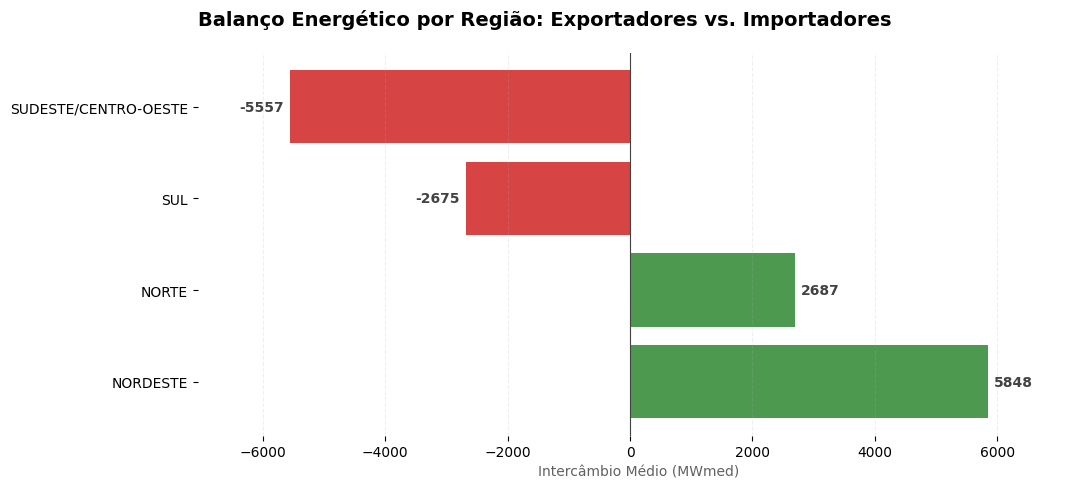

In [12]:
# filtrando o SIN para comparar apenas as regioes
df_regioes = df_202526[df_202526['nom_subsistema'] != 'SISTEMA INTERLIGADO NACIONAL'].copy()

# agregacao por regiao
df_comp = df_regioes.groupby('nom_subsistema')['val_intercambio'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(11, 5))
cores_custom = ['#388E3C' if x > 0 else '#D32F2F' for x in df_comp['val_intercambio']]

barras = plt.barh(df_comp['nom_subsistema'], df_comp['val_intercambio'],
                  color=cores_custom, alpha=0.9)

# aumentando o limite do eixo X para o numero nao bater na borda ou no texto
plt.xlim(df_comp['val_intercambio'].min() - 1500, df_comp['val_intercambio'].max() + 1500)

for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.axvline(0, color='#424242', linewidth=0.8)

plt.title('Balanço Energético por Região: Exportadores vs. Importadores',
          fontsize=14, fontweight='bold', pad=20, loc='left')
plt.xlabel('Intercâmbio Médio (MWmed)', fontsize=10, color='#616161')
plt.grid(axis='x', linestyle='--', alpha=0.2)

# ajuste fino dos rotulos para nao sobrepor
for i, v in enumerate(df_comp['val_intercambio']):
    ha_val = 'left' if v > 0 else 'right'
    offset = 100 if v > 0 else -100
    plt.text(v + offset, i, f'{int(v)}', va='center',
             fontsize=10, fontweight='bold', color='#424242', ha=ha_val)

plt.tight_layout()
plt.show()


Antes de aprofundar na operação regional, esta visualização compara o Intercâmbio Médio Líquido de todos os subsistemas brasileiros. O objetivo é validar estatisticamente a premissa de que **o Nordeste atua como o principal supridor de energia** excedente para o Sistema Interligado Nacional (SIN), justificando o foco técnico deste estudo de caso na infraestrutura desta região.

*Obervação: O dataset original contém o consolidado do SIN na mesma coluna dos subsistemas regionais. Para esta visualização comparativa, optei por filtrar o SIN e manter apenas os recortes geográficos (Norte, Nordeste, Sul e Sudeste/Centro-Oeste), permitindo uma análise direta da balança energética entre as regiões brasileiras.*

### 2.2 Dinâmica Temporal: Sazonalidade da Capacidade Exportadora

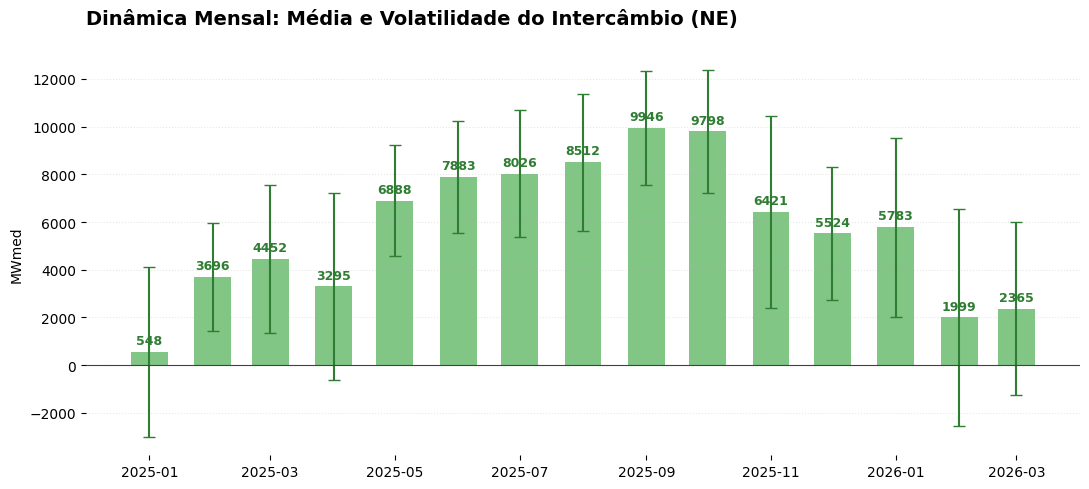

In [13]:
# calculo da media e o desvio padrao do intercambio
resumo_mensal = df_ne.groupby(['ano', 'mes'])['val_intercambio'].agg(['mean', 'std']).reset_index()

# tratamento da linha do tempo para o eixo X
resumo_mensal['data'] = pd.to_datetime(resumo_mensal.rename(columns={'ano': 'year', 'mes': 'month'}).assign(day=1)[['year', 'month', 'day']])
resumo_mensal = resumo_mensal.sort_values('data')

plt.figure(figsize=(11, 5))

# Plotagem das barras com barras de erro (yerr) representando o desvio padrao
barras = plt.bar(resumo_mensal['data'], resumo_mensal['mean'],
                 yerr=resumo_mensal['std'], capsize=4,
                 color='#4CAF50', width=18, alpha=0.7, ecolor='#2E7D32')

plt.axhline(0, color='#424242', linewidth=0.8)

for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.title('Dinâmica Mensal: Média e Volatilidade do Intercâmbio (NE)',
          fontsize=14, fontweight='bold', loc='left', pad=20)
plt.ylabel('MWmed', fontsize=10)
plt.grid(axis='y', linestyle=':', alpha=0.3)

# rotulos de dados para as medias
for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + 200, f'{int(yval)}',
             ha='center', va='bottom', fontsize=9, fontweight='bold', color='#2E7D32')

plt.tight_layout()
plt.show()

Após consolidar o Nordeste como o principal provedor do SIN, no gráfico anterior, analisei a série temporal das médias mensais (2025-2026) para identificar padrões de comportamento. Os dados revelam que a capacidade de exportação não é linear, apresentando uma forte dependência da sazonalidade climática — como a 'safra dos ventos' e os períodos de seca. O desvio padrão acentuado entre os meses (variando de ~500 MWmed a quase 10.000 MWmed) demonstra que a segurança do sistema não pode depender de médias estáticas. Isso justifica o uso de modelos estocásticos e preditivos, pois a rede nacional precisa estar preparada para oscilações drásticas na oferta regional.

*Optei pelo gráfico de barras porque ele enfatiza o volume mensal acumulado de exportação, facilitando a comparação entre períodos distintos. Adicionei o desvio padrão (barras de erro) para não ocultar a volatilidade intra-mensal, demonstrando que, embora o Nordeste seja um exportador robusto, ele opera sob forte regime estocástico.*

### 2.3 Balanço de Oferta e Demanda (Subsistema Nordeste)

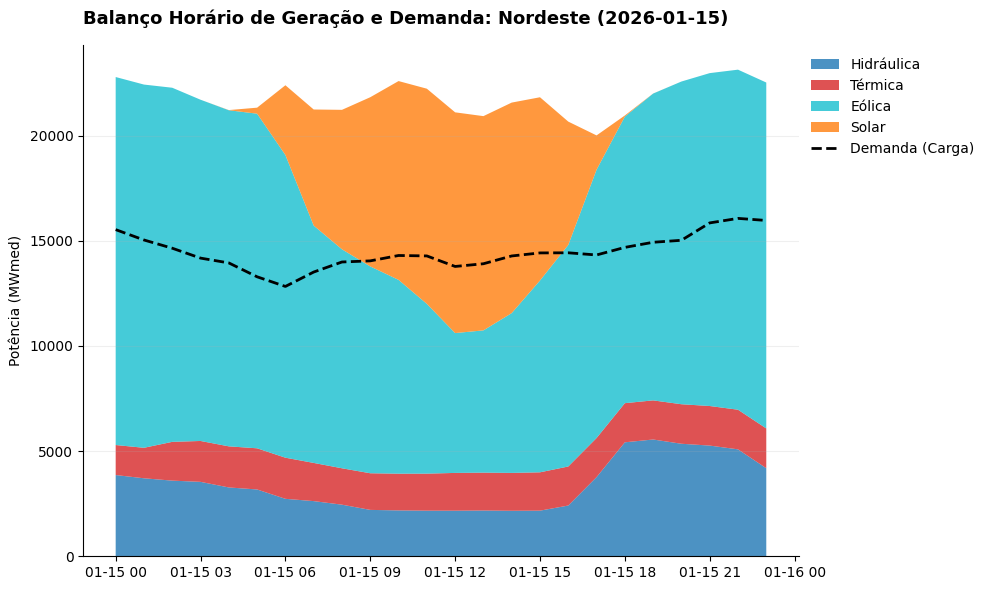

In [14]:
# filtro para um dia de operação padrao
dia_analise = '2026-01-15'
df_dia = df_ne[df_ne['din_instante'].dt.strftime('%Y-%m-%d') == dia_analise].copy()

plt.figure(figsize=(10, 6))

# definicao de cores e labels para a composição da matriz
cores_matriz = ['#1f77b4', '#d62728', '#17becf', '#ff7f0e']
fontes = ['Hidráulica', 'Térmica', 'Eólica', 'Solar']

# geracao do Stackplot para análise parte-todo
plt.stackplot(df_dia['din_instante'],
              df_dia['val_gerhidraulica'], df_dia['val_gertermica'],
              df_dia['val_gereolica'], df_dia['val_gersolar'],
              labels=fontes, colors=cores_matriz, alpha=0.8)

# sobreposicao da linha de carga para verificar o balanco local
plt.plot(df_dia['din_instante'], df_dia['val_carga'], color='black',
         linestyle='--', linewidth=2, label='Demanda (Carga)')

# ajustes de layout e remocao de bordas (lixo visual)
plt.title(f'Balanço Horário de Geração e Demanda: Nordeste ({dia_analise})',
          fontsize=13, fontweight='bold', loc='left', pad=15)
plt.ylabel('Potência (MWmed)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=False)
plt.grid(axis='y', alpha=0.2)

for spine in plt.gca().spines.values():
    if spine.spine_type in ['top', 'right']:
        spine.set_visible(False)

plt.tight_layout()
plt.show()

Para entender a dinâmica operativa que sustenta a exportação regional, selecionei um ciclo de 24 horas (15/01/2026). O objetivo desta visualização de áreas empilhadas (Stackplot) é observar a interação entre as fontes de base (Hidráulica e Térmica) e as fontes de alta variabilidade (Eólica e Solar). Esta análise permite identificar como o sistema se comporta frente à carga e em que momentos o excedente de geração se torna mais acentuado, transformando o Nordeste em um polo supridor para o restante do país.

*Optei pelo uso do **Stackplot** porque é a única visualização que permite ver a composição da matriz (as fatias coloridas) e o total gerado (a linha de cima do gráfico) simultaneamente. Num gráfico de linhas, por exemplo, as fontes ficariam cruzadas e seria difícil perceber que a soma delas é que atende a carga. Ele destaca o domínio das renováveis (Eólica e Solar) sobre as fontes fósseis (Térmica). Fica visualmente óbvio como uma fonte "entra" quando a outra "sai".*

### 2.4 Identificação de Cenários Críticos: Estresse Operacional

Para validar a resiliência do sistema, utilizei a função idxmax() para localizar o evento de carga máxima em todo o dataset (04/02/2026). O objetivo é contrastar a operação típica com um cenário de estresse severo. Como observado na Figura, o excedente de geração (área colorida acima da linha tracejada) diminui drasticamente no período noturno, revelando que o Nordeste, embora exportador na média, enfrenta momentos de vulnerabilidade onde a geração local não supre a demanda interna.

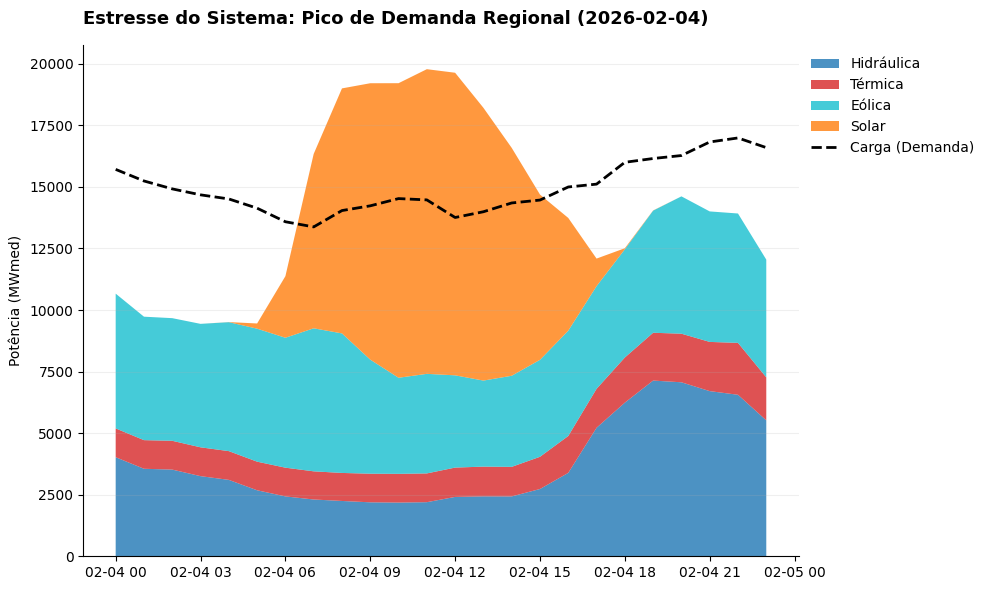

In [15]:
# localizacao estatistica do pico de demanda no subsistema
instante_pico = df_ne.loc[df_ne['val_carga'].idxmax(), 'din_instante']
dia_pico = instante_pico.strftime('%Y-%m-%d')

# filtragem do recorte temporal de 24h para o cenario de estresse
df_pico = df_ne[df_ne['din_instante'].dt.strftime('%Y-%m-%d') == dia_pico].copy()

plt.figure(figsize=(10, 6))

# Representacao da matriz energwtica no limite operacional
plt.stackplot(df_pico['din_instante'],
              df_pico['val_gerhidraulica'], df_pico['val_gertermica'],
              df_pico['val_gereolica'], df_pico['val_gersolar'],
              labels=['Hidráulica', 'Térmica', 'Eólica', 'Solar'],
              colors=['#1f77b4', '#d62728', '#17becf', '#ff7f0e'], alpha=0.8)

plt.plot(df_pico['din_instante'], df_pico['val_carga'], color='black',
         linestyle='--', linewidth=2, label='Carga (Demanda)')

plt.title(f'Estresse do Sistema: Pico de Demanda Regional ({dia_pico})',
          fontsize=13, fontweight='bold', loc='left', pad=15)
plt.ylabel('Potência (MWmed)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=False)
plt.grid(axis='y', alpha=0.2)

for spine in plt.gca().spines.values():
    if spine.spine_type in ['top', 'right']:
        spine.set_visible(False)

plt.tight_layout()
plt.show()

A análise do dia de carga máxima (04/02/2026) revela um cenário de estresse operacional severo no subsistema Nordeste. Diferente de dias típicos, observa-se que no pico de demanda noturno (após as 18h), a geração regional total foi insuficiente para suprir a carga, exigindo a importação de energia via intercâmbio. Este gráfico evidencia a vulnerabilidade do sistema durante a rampa de descida da fonte solar, especialmente em dias de alta demanda térmica, onde a intermitência das renováveis atinge seu ponto mais crítico para a segurança do SIN.

### 2.5 O Gargalo das renováveis:

#### O Fenômeno da Rampa Solar vs. Carga:

Isolamos apenas a Geração Solar e a Carga (Demanda) utilizando o dia de estresse operacional identificado (04/02/2026). O objetivo é evidenciar o "descruzamento" das curvas: o momento exato em que a fonte solar encerra seu ciclo diário enquanto a demanda atinge seu pico. Este descompasso é o principal desafio para a estabilidade de frequência e tensão na rede elétrica regional.

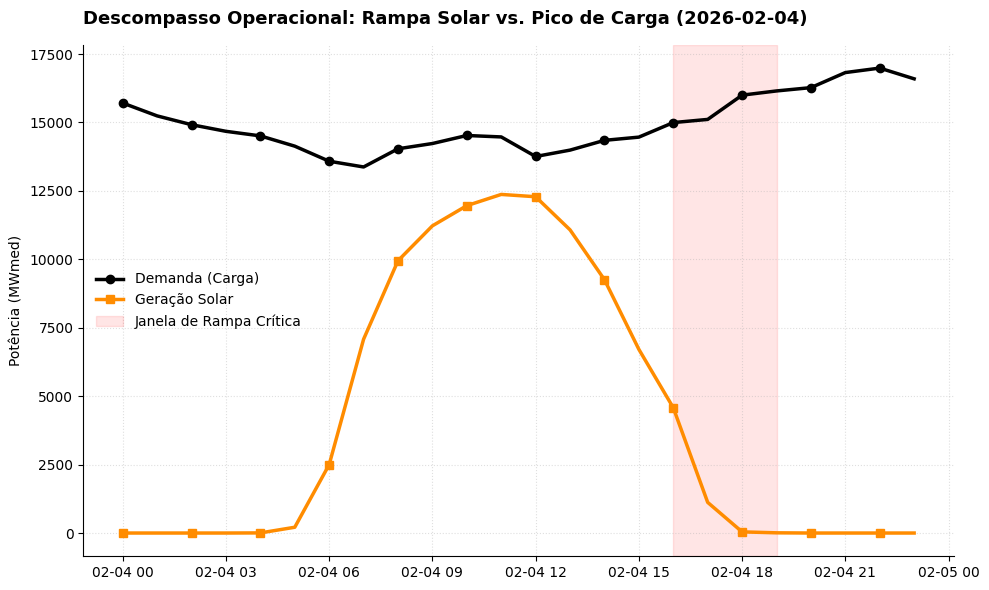

In [16]:
# recorte focado na janela de desequilibrio solar vs. carga
dia_zoom = '2026-02-04'
df_zoom = df_ne[df_ne['din_instante'].dt.strftime('%Y-%m-%d') == dia_zoom].copy()

plt.figure(figsize=(10, 6))

# visualizacao das tendencias opostas (Supply vs. Demand)
plt.plot(df_zoom['din_instante'], df_zoom['val_carga'],
         color='black', linewidth=2.5, label='Demanda (Carga)', marker='o', markevery=2)

plt.plot(df_zoom['din_instante'], df_zoom['val_gersolar'],
         color='#FF8C00', linewidth=2.5, label='Geração Solar', marker='s', markevery=2)

# marcacao da zona de estresse operacional para analise de rampa
plt.axvspan(pd.to_datetime(f'{dia_zoom} 16:00:00'),
            pd.to_datetime(f'{dia_zoom} 19:00:00'),
            color='red', alpha=0.1, label='Janela de Rampa Crítica')

plt.title(f'Descompasso Operacional: Rampa Solar vs. Pico de Carga ({dia_zoom})',
          fontsize=13, fontweight='bold', loc='left', pad=15)

plt.ylabel('Potência (MWmed)')
plt.legend(frameon=False)
plt.grid(True, linestyle=':', alpha=0.4)

# removendo o lixo visual
for spine in plt.gca().spines.values():
    if spine.spine_type in ['top', 'right']:
        spine.set_visible(False)

plt.tight_layout()
plt.show()

#### Variabilidade e Volatilidade da Fonte Eólica:

Diferente da fonte solar, cuja ciclicidade é previsível (dia/noite), a geração eólica apresenta alta volatilidade estocástica. Esta visualização analisa uma semana completa de dados para demonstrar como a geração eólica pode oscilar bruscamente em curtos intervalos de tempo. Esta característica reforça o Desafio da necessidade de fontes de reserva e de algoritmos de IA para predição de ventos, visando garantir a resiliência do sistema frente a quedas inesperadas de produção.

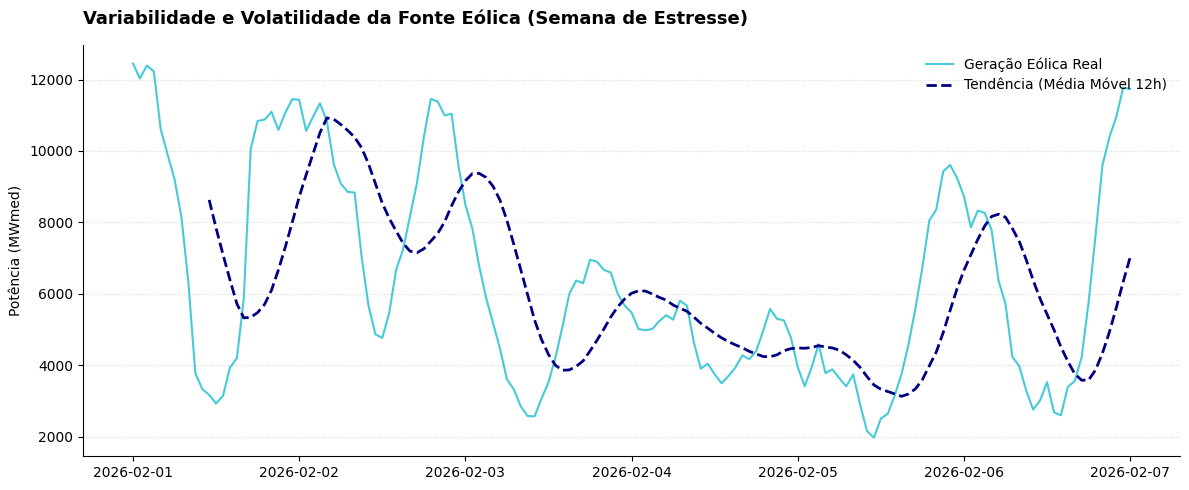

In [17]:
# recorte temporal de sete dias para analise de volatilidade eolica
data_inicio, data_fim = '2026-02-01', '2026-02-07'
df_semana = df_ne[(df_ne['din_instante'] >= data_inicio) & (df_ne['din_instante'] <= data_fim)].copy()

plt.figure(figsize=(12, 5))

# plotagem do dado bruto (alta frequwncia) vs. tendwncia suavizada
plt.plot(df_semana['din_instante'], df_semana['val_gereolica'],
         color='#17becf', linewidth=1.5, alpha=0.8, label='Geração Eólica Real')

# media movel de 12 horas para evidenciar o ruido estatistico
plt.plot(df_semana['din_instante'], df_semana['val_gereolica'].rolling(window=12).mean(),
         color='navy', linestyle='--', linewidth=2, label='Tendência (Média Móvel 12h)')

plt.title('Variabilidade e Volatilidade da Fonte Eólica (Semana de Estresse)',
          fontsize=13, fontweight='bold', loc='left', pad=15)

plt.ylabel('Potência (MWmed)')
plt.legend(frameon=False, loc='upper right')
plt.grid(axis='y', linestyle=':', alpha=0.5)

# remocao do lixo visual
for spine in plt.gca().spines.values():
    if spine.spine_type in ['top', 'right']:
        spine.set_visible(False)

plt.tight_layout()
plt.show()

Note que, ao contrário do sol que tem um desenho de "morrinho" igual todo dia, o vento não tem padrão. No dia 02-05, a geração eólica despencou para quase 2.000 MWmed, enquanto no dia 01-02 ela estava acima de 12.000.

A linha roxa mostra a tendência. Perceba como a linha ciano (dado real) "escapa" da média o tempo todo. Algoritmos de Deep Learning (como LSTMs) seriam ideais para prever essas oscilações que a média móvel simples não consegue captar.

**IV. Takeaways (Conclusões Principais):**
A análise integrada demonstra que o Nordeste é o pilar da segurança energética brasileira, mantendo superávits de exportação persistentes. Contudo, a segurança dessa operação é vulnerável à volatilidade horária. O risco crítico identificado não é a escassez de energia, mas a severidade da rampa de variação. A integridade do SIN depende da mitigação desse descompasso para evitar a sobrecarga das interligações regionais durante o declínio.

**V. Análise de Viabilidade Técnica e Inovação:**
Diante da natureza estocástica dos ventos e da ciclicidade solar, o estudo valida a necessidade de arquiteturas de Smart Grids orientadas por dados:
* Predição de Curto Prazo: Implementação de modelos de Deep Learning (Redes Neurais) para previsão de rampas solares, permitindo um despacho preventivo e otimizado de fontes despacháveis.
* Sistemas de Armazenamento (BESS): A viabilidade de baterias de grande escala para absorver o excedente de geração diurna identificado, realizando o peak shaving (alívio do pico) e garantindo a resiliência sistêmica sem dependência térmica.